In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
from torchvision.models import resnet18, ResNet18_Weights


In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [3]:
!unzip "archive.zip"

Archive:  archive.zip
  inflating: NEU-DET/train/annotations/crazing_1.xml  
  inflating: NEU-DET/train/annotations/crazing_10.xml  
  inflating: NEU-DET/train/annotations/crazing_100.xml  
  inflating: NEU-DET/train/annotations/crazing_101.xml  
  inflating: NEU-DET/train/annotations/crazing_102.xml  
  inflating: NEU-DET/train/annotations/crazing_103.xml  
  inflating: NEU-DET/train/annotations/crazing_104.xml  
  inflating: NEU-DET/train/annotations/crazing_105.xml  
  inflating: NEU-DET/train/annotations/crazing_106.xml  
  inflating: NEU-DET/train/annotations/crazing_107.xml  
  inflating: NEU-DET/train/annotations/crazing_108.xml  
  inflating: NEU-DET/train/annotations/crazing_109.xml  
  inflating: NEU-DET/train/annotations/crazing_11.xml  
  inflating: NEU-DET/train/annotations/crazing_110.xml  
  inflating: NEU-DET/train/annotations/crazing_111.xml  
  inflating: NEU-DET/train/annotations/crazing_112.xml  
  inflating: NEU-DET/train/annotations/crazing_113.xml  
  inflating: 

In [4]:
train="NEU-DET/train/images"
test="NEU-DET/validation/images"

In [5]:
train_transforming=transforms.Compose([transforms.Resize((224,224)),
                                       transforms.RandomHorizontalFlip(),transforms.ColorJitter()
                                       ,transforms.RandomRotation(10),transforms.ToTensor(),transforms.Normalize(mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])])
test_transforming=transforms.Compose([transforms.Resize((224,224)),transforms.ToTensor(),transforms.Normalize(mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])])

In [6]:
train_data=datasets.ImageFolder(train,transform=train_transforming)
test_data=datasets.ImageFolder(test,transform=test_transforming)
print("Classes:",train_data.classes)
print("Number of classes:",len(train_data.classes))

Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Number of classes: 6


In [7]:
train_loader=DataLoader(train_data,batch_size=32,shuffle=True)
test_loader=DataLoader(test_data,batch_size=32,shuffle=False)

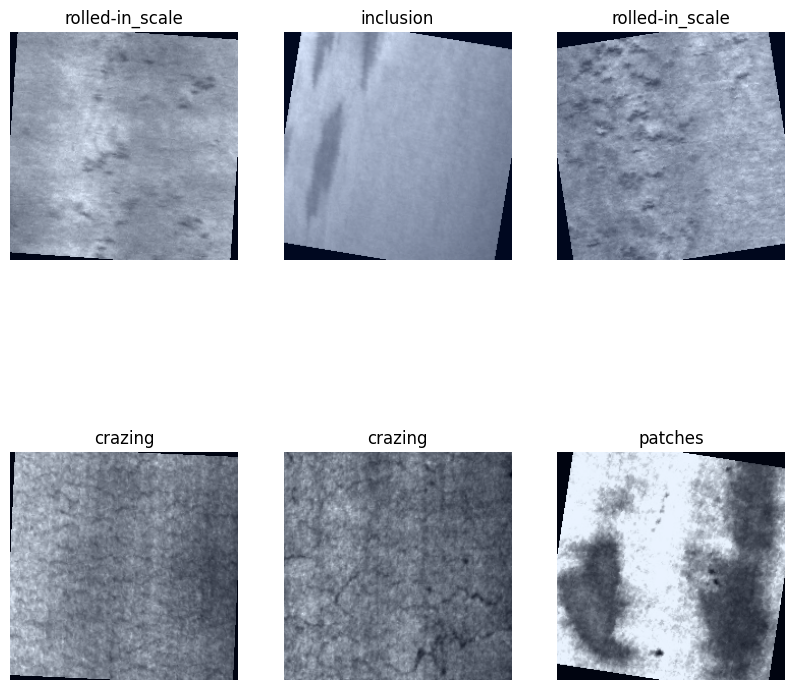

In [8]:
images,labels=next(iter(train_loader))

plt.figure(figsize=(10,10))
for i in range(6):
  plt.subplot(2,3,i+1)
  img=images[i].permute(1,2,0).numpy()
  img=(img-img.min())/(img.max()-img.min())
  plt.imshow(img)
  plt.title(train_data.classes[labels[i]])
  plt.axis("off")

plt.show()

In [9]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [10]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=SimpleCNN(num_classes=len(train_data.classes))
model.to(device)

criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)

In [11]:
def train_model(model,train_loader,test_loader,criterion,optimizer,num_epochs=20):
  for epoch in range(num_epochs):
    model.train()
    train_loss=0
    correct=0
    total=0

    for images,labels in train_loader:
      images=images.to(device)
      labels=labels.to(device)

      optimizer.zero_grad()
      outputs=model(images)
      loss=criterion(outputs,labels)
      loss.backward()
      optimizer.step()

      train_loss+=loss.item()
      _,predicted=torch.max(outputs.data,1)
      total+=labels.size(0)
      correct+=(predicted==labels).sum().item()

    train_acc=100*correct/total

    model.eval()
    val_loss=0
    correct=0
    total=0

    with torch.no_grad():
      for images,labels in test_loader:
        images=images.to(device)
        labels=labels.to(device)

        outputs=model(images)
        loss=criterion(outputs,labels)
        val_loss+=loss.item()

        _,predicted=torch.max(outputs.data,1)
        total+=labels.size(0)
        correct+=(predicted==labels).sum().item()

    val_acc=100*correct/total
    print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss/len(train_loader):.4f} | "
              f"Train Acc: {train_acc:.4f} | "
              f"Val Acc: {val_acc:.4f}")

In [12]:
train_model(model,train_loader,test_loader,criterion,optimizer,num_epochs=20)

Epoch [1/20] Train Loss: 1.4018 | Train Acc: 51.4583 | Val Acc: 43.3333
Epoch [2/20] Train Loss: 0.6183 | Train Acc: 78.8889 | Val Acc: 80.5556
Epoch [3/20] Train Loss: 0.4191 | Train Acc: 85.7639 | Val Acc: 73.6111
Epoch [4/20] Train Loss: 0.3600 | Train Acc: 88.2639 | Val Acc: 85.8333
Epoch [5/20] Train Loss: 0.2892 | Train Acc: 90.6944 | Val Acc: 80.2778
Epoch [6/20] Train Loss: 0.2817 | Train Acc: 91.6667 | Val Acc: 86.9444
Epoch [7/20] Train Loss: 0.2711 | Train Acc: 91.1111 | Val Acc: 85.8333
Epoch [8/20] Train Loss: 0.2100 | Train Acc: 93.4028 | Val Acc: 80.5556
Epoch [9/20] Train Loss: 0.2167 | Train Acc: 93.2639 | Val Acc: 81.9444
Epoch [10/20] Train Loss: 0.1750 | Train Acc: 94.7222 | Val Acc: 83.0556
Epoch [11/20] Train Loss: 0.1477 | Train Acc: 95.3472 | Val Acc: 89.4444
Epoch [12/20] Train Loss: 0.1712 | Train Acc: 94.5139 | Val Acc: 86.9444
Epoch [13/20] Train Loss: 0.1657 | Train Acc: 95.5556 | Val Acc: 91.3889
Epoch [14/20] Train Loss: 0.1700 | Train Acc: 94.7222 | Val 

In [13]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


In [14]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=train_data.classes
))


                 precision    recall  f1-score   support

        crazing       0.90      1.00      0.94        60
      inclusion       0.93      0.63      0.75        60
        patches       0.98      0.88      0.93        60
 pitted_surface       0.70      0.95      0.80        60
rolled-in_scale       0.94      1.00      0.97        60
      scratches       1.00      0.87      0.93        60

       accuracy                           0.89       360
      macro avg       0.91      0.89      0.89       360
   weighted avg       0.91      0.89      0.89       360



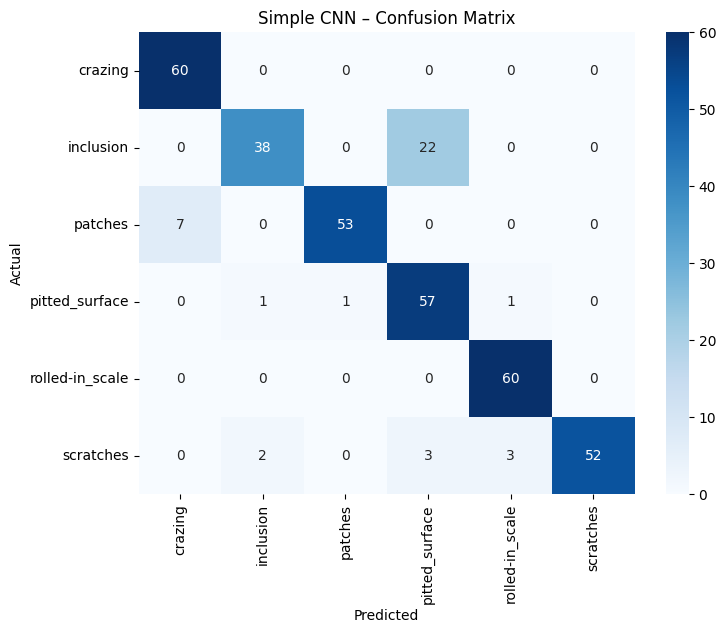

In [15]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_data.classes,
    yticklabels=train_data.classes
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Simple CNN – Confusion Matrix")
plt.show()

In [16]:
misclassified = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for i in range(len(labels)):
            if preds[i] != labels[i]:
                misclassified.append({
                    "image": images[i].cpu(),
                    "true": labels[i].cpu().item(),
                    "pred": preds[i].cpu().item()
                })


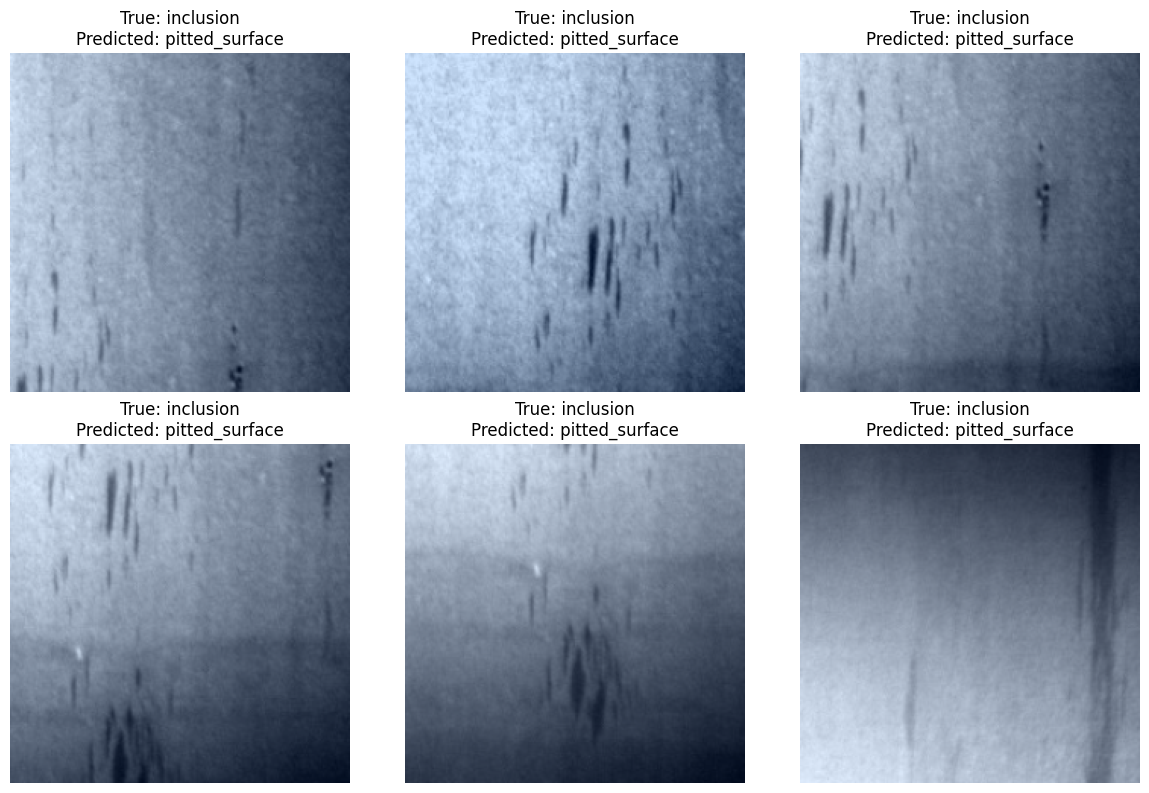

In [17]:
def show_misclassified(samples, class_names, n=6):
    plt.figure(figsize=(12, 8))
    for i in range(n):
        sample = samples[i]
        img = sample["image"].permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min())

        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title(f"True: {class_names[sample['true']]}\nPredicted: {class_names[sample['pred']]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_misclassified(misclassified, train_data.classes, n=6)


In [18]:
weights=ResNet18_Weights.IMAGENET1K_V1
resnet=resnet18(weights=weights)

for param in resnet.parameters():
  param.requires_grad=False

num_classes=len(train_data.classes)

resnet.fc=nn.Sequential(nn.Linear(512,256),
                        nn.ReLU(),nn.Dropout(0.5),nn.Linear(256,num_classes))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 209MB/s]


In [19]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet.to(device)

criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(resnet.fc.parameters(),lr=0.001)

In [20]:
train_model(resnet,train_loader,test_loader,criterion,optimizer,num_epochs=15)

Epoch [1/15] Train Loss: 0.7985 | Train Acc: 74.1667 | Val Acc: 77.5000
Epoch [2/15] Train Loss: 0.2478 | Train Acc: 92.5000 | Val Acc: 90.5556
Epoch [3/15] Train Loss: 0.1656 | Train Acc: 95.4861 | Val Acc: 95.5556
Epoch [4/15] Train Loss: 0.1337 | Train Acc: 95.9028 | Val Acc: 89.1667
Epoch [5/15] Train Loss: 0.1365 | Train Acc: 95.2778 | Val Acc: 96.9444
Epoch [6/15] Train Loss: 0.1030 | Train Acc: 96.8056 | Val Acc: 98.0556
Epoch [7/15] Train Loss: 0.0910 | Train Acc: 97.3611 | Val Acc: 94.1667
Epoch [8/15] Train Loss: 0.0656 | Train Acc: 97.8472 | Val Acc: 96.6667
Epoch [9/15] Train Loss: 0.0862 | Train Acc: 97.5694 | Val Acc: 94.1667
Epoch [10/15] Train Loss: 0.0873 | Train Acc: 97.1528 | Val Acc: 96.3889
Epoch [11/15] Train Loss: 0.0950 | Train Acc: 97.0139 | Val Acc: 99.1667
Epoch [12/15] Train Loss: 0.0756 | Train Acc: 97.3611 | Val Acc: 99.4444
Epoch [13/15] Train Loss: 0.0758 | Train Acc: 97.1528 | Val Acc: 94.4444
Epoch [14/15] Train Loss: 0.0766 | Train Acc: 97.1528 | Val 

In [21]:
resnet.eval()
all_preds=[]
all_labels=[]

with torch.no_grad():
  for images,labels in test_loader:
    images=images.to(device)
    labels=labels.to(device)

    outputs=resnet(images)
    _,preds=torch.max(outputs,1)

    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())
print(classification_report(all_labels,all_preds,target_names=train_data.classes))


                 precision    recall  f1-score   support

        crazing       0.91      1.00      0.95        60
      inclusion       1.00      0.88      0.94        60
        patches       1.00      1.00      1.00        60
 pitted_surface       1.00      0.98      0.99        60
rolled-in_scale       1.00      0.92      0.96        60
      scratches       0.90      1.00      0.94        60

       accuracy                           0.96       360
      macro avg       0.97      0.96      0.96       360
   weighted avg       0.97      0.96      0.96       360



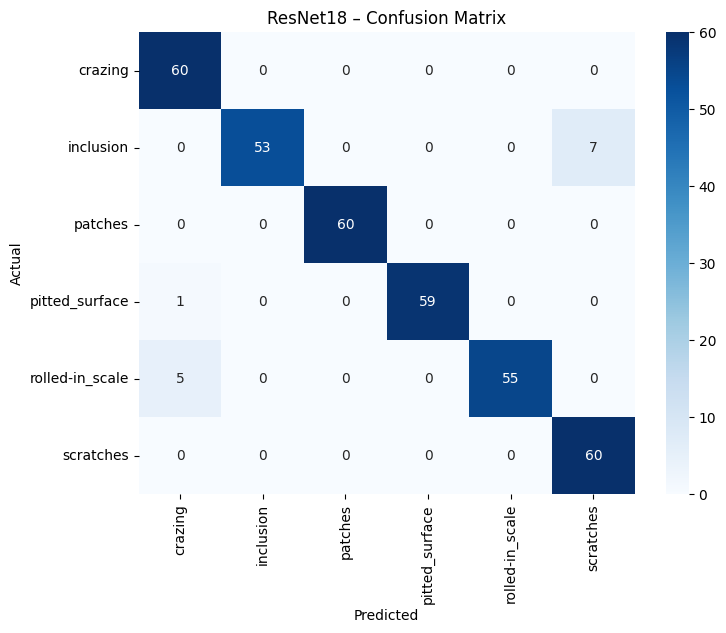

In [22]:
cm=confusion_matrix(all_labels,all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=train_data.classes,yticklabels=train_data.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet18 – Confusion Matrix")
plt.show()

In [23]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    all_labels,
    all_preds,
    target_names=train_data.classes,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()
df_report


,precision,recall,f1-score,support
crazing,0.909091,1.000000,0.952381,60.000000
inclusion,1.000000,0.883333,0.938053,60.000000
patches,1.000000,1.000000,1.000000,60.000000
pitted_surface,1.000000,0.983333,0.991597,60.000000
rolled-in_scale,1.000000,0.916667,0.956522,60.000000
scratches,0.895522,1.000000,0.944882,60.000000
accuracy,0.963889,0.963889,0.963889,0.963889
macro avg,0.967436,0.963889,0.963906,360.000000
weighted avg,0.967436,0.963889,0.963906,360.000000


In [24]:
# Exclude avg/accuracy rows
class_metrics = df_report.iloc[:-3]

# Lowest recall (most missed defects)
lowest_recall = class_metrics['recall'].idxmin()
lowest_recall_value = class_metrics.loc[lowest_recall, 'recall']

# Highest recall (easiest defects)
highest_recall = class_metrics['recall'].idxmax()
highest_recall_value = class_metrics.loc[highest_recall, 'recall']

print(f"Lowest Recall Class: {lowest_recall} ({lowest_recall_value:.2f})")
print(f"Highest Recall Class: {highest_recall} ({highest_recall_value:.2f})")


Lowest Recall Class: inclusion (0.88)
Highest Recall Class: crazing (1.00)


In [25]:
precision_recall_gap = (
    class_metrics['precision'] - class_metrics['recall']
).abs().sort_values(ascending=False)

precision_recall_gap


,0
inclusion,0.116667
scratches,0.104478
crazing,0.090909
rolled-in_scale,0.083333
pitted_surface,0.016667
patches,0.000000


In [26]:
confusion_pairs = []

for i, true_label in enumerate(train_data.classes):
    for j, pred_label in enumerate(train_data.classes):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append({
                "True": true_label,
                "Predicted": pred_label,
                "Count": cm[i, j]
            })

confusion_df = pd.DataFrame(confusion_pairs)
confusion_df.sort_values("Count", ascending=False).head(5)


,True,Predicted,Count
0,inclusion,scratches,7
2,rolled-in_scale,crazing,5
1,pitted_surface,crazing,1


In [27]:
total_errors = sum(cm[i, j] for i in range(len(cm)) for j in range(len(cm)) if i != j)

top_confusions = confusion_df.sort_values("Count", ascending=False).head(3)
top_error_sum = top_confusions["Count"].sum()

print(f"Total errors: {total_errors}")
print(f"Top 3 confusion errors: {top_error_sum}")
print(f"Error concentration (%): {(top_error_sum / total_errors) * 100:.2f}%")


Total errors: 13
Top 3 confusion errors: 13
Error concentration (%): 100.00%


<Figure size 900x500 with 0 Axes>

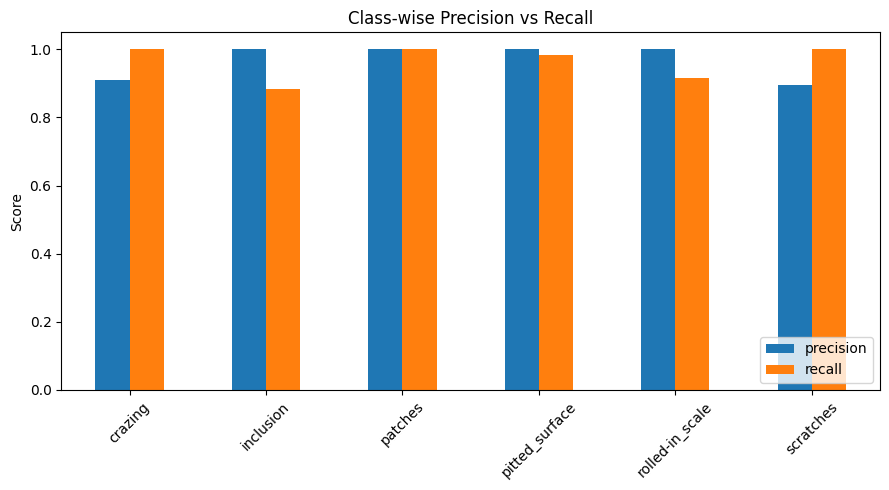

In [28]:
plt.figure(figsize=(9,5))

class_metrics[['precision', 'recall']].plot(
    kind='bar',
    figsize=(9,5)
)

plt.title("Class-wise Precision vs Recall")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


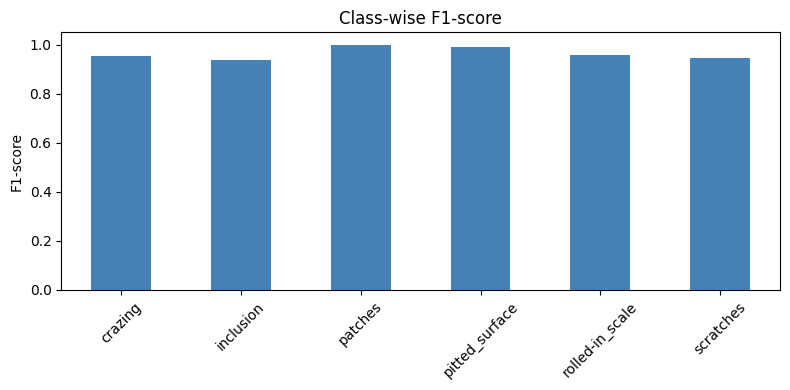

In [29]:
plt.figure(figsize=(8,4))

class_metrics['f1-score'].plot(
    kind='bar',
    color='steelblue'
)

plt.title("Class-wise F1-score")
plt.ylabel("F1-score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


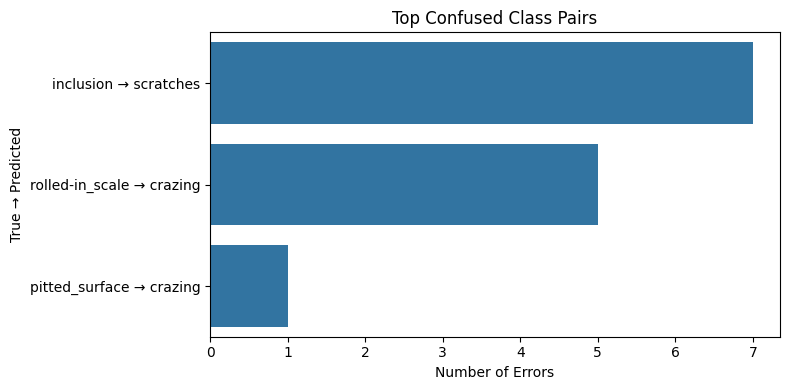

In [30]:
top_confusions = confusion_df.sort_values("Count", ascending=False).head(5)

plt.figure(figsize=(8,4))
sns.barplot(
    data=top_confusions,
    x="Count",
    y=top_confusions["True"] + " → " + top_confusions["Predicted"]
)

plt.title("Top Confused Class Pairs")
plt.xlabel("Number of Errors")
plt.ylabel("True → Predicted")
plt.tight_layout()
plt.show()


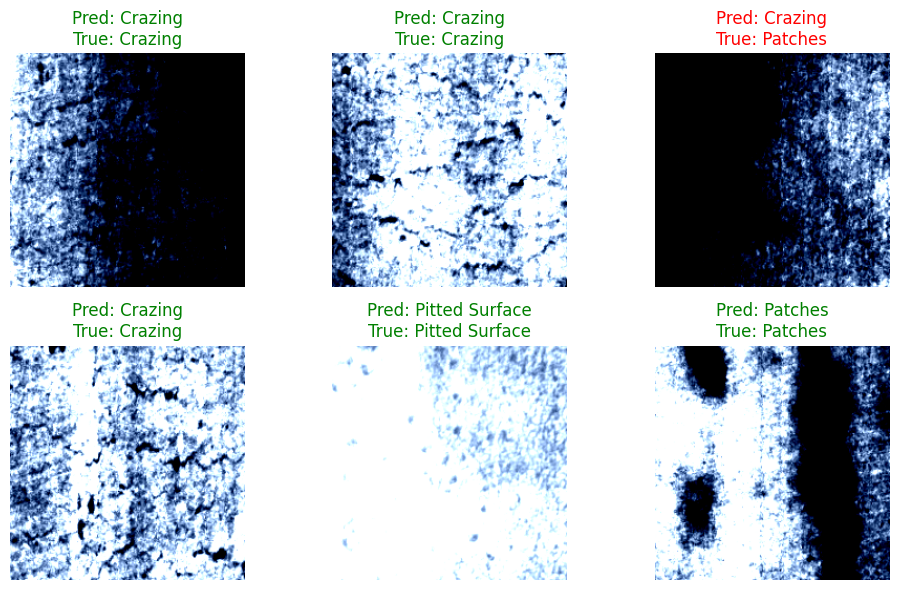

In [40]:
import matplotlib.pyplot as plt
import random

class_names = [
    "Crazing",
    "Inclusion",
    "Patches",
    "Pitted Surface",
    "Rolled-in Scale",
    "Scratches"
]

model.eval()

all_images = []
all_preds = []
all_labels = []

# collect predictions from entire test set
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_images.extend(images.cpu())
        all_preds.extend(preds.cpu())
        all_labels.extend(labels.cpu())

# pick random indices
indices = random.sample(range(len(all_images)), 6)

fig, axes = plt.subplots(2, 3, figsize=(10,6))

for i, ax in enumerate(axes.flat):
    idx = indices[i]

    img = all_images[idx].permute(1,2,0)
    pred = all_preds[idx]
    label = all_labels[idx]

    color = "green" if pred == label else "red"

    ax.imshow(img)
    ax.set_title(
        f"Pred: {class_names[pred]}\nTrue: {class_names[label]}",
        color=color
    )
    ax.axis("off")

plt.tight_layout()
plt.show()